# Vision Transformer (ViT) — Classification de panneaux de signalisation (GTSRB)

**Dataset** : German Traffic Sign Recognition Benchmark (43 classes, images 32×32)  
**Architecture** : Vision Transformer (ViT) — implémentation complète from scratch  
**Données** : `data3.pickle` — RGB, shuffle + normalisation /255 + mean + std

---

## Qu'est-ce qu'un Transformer ?

Le Transformer a été introduit en 2017 dans l'article *"Attention Is All You Need"* (Vaswani et al.)  
pour le traitement du langage naturel (NLP). Son principe central : **l'attention** — chaque élément  
d'une séquence peut regarder tous les autres éléments pour enrichir sa représentation.

## Qu'est-ce qu'un Vision Transformer (ViT) ?

En 2020, Dosovitskiy et al. (*"An Image is Worth 16×16 Words"*) ont adapté cette idée aux images :  
au lieu de traiter des mots, on traite des **patches** (morceaux d'image).  
Chaque patch est comme un "mot" dans une phrase — le Transformer apprend les relations entre eux.

```
Image 32×32 (3 canaux)
        │
        ▼ Découpage en patches 4×4
  64 patches de 4×4×3 = 48 pixels
        │
        ▼ Projection linéaire (Patch Embedding)
  64 vecteurs de dimension D=128
        │
        ▼ + CLS token + Position Embedding
  65 vecteurs de dimension D=128
        │
        ▼ L blocs Transformer (Attention + MLP)
  65 vecteurs enrichis
        │
        ▼ CLS token final → tête de classification
  43 logits (une valeur par classe)
```

## 1. Imports

In [1]:
import pickle
import csv
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

Device : cpu


## 2. Chargement des données

In [2]:
with open('data3.pickle', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

x_train = data['x_train'].astype(np.float32)       # (N, 3, 32, 32)
y_train = data['y_train'].astype(np.int64)          # (N,)
x_val   = data['x_validation'].astype(np.float32)  # (M, 3, 32, 32)
y_val   = data['y_validation'].astype(np.int64)     # (M,)
x_test  = data['x_test'].astype(np.float32)         # (K, 3, 32, 32)
y_test  = data['y_test'].astype(np.int64)            # (K,)

def load_label_names(file):
    names = []
    with open(file, 'r') as f:
        reader = csv.reader(f)
        for row in reader:
            names.append(row[1])
    return names[1:]

label_names = load_label_names('label_names.csv')
NUM_CLASSES = len(label_names)

print(f'Train      : {x_train.shape}')
print(f'Validation : {x_val.shape}')
print(f'Test       : {x_test.shape}')
print(f'Classes    : {NUM_CLASSES}')

Train      : (86989, 3, 32, 32)
Validation : (4410, 3, 32, 32)
Test       : (12630, 3, 32, 32)
Classes    : 43


## 3. DataLoaders

In [3]:
BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val)),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test)),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

print(f'Batches train : {len(train_loader)}')
print(f'Batches val   : {len(val_loader)}')
print(f'Batches test  : {len(test_loader)}')

Batches train : 680
Batches val   : 35
Batches test  : 99


## 4. Architecture : Vision Transformer

### 4.1 Patch Embedding

**Problème** : un CNN utilise des convolutions locales. Un Transformer travaille sur des séquences.  
**Solution** : découper l'image en patches et traiter chaque patch comme un "token".

**Comment ça marche :**
1. On divise l'image 32×32 en patches de 4×4 pixels
2. Nombre de patches = (32÷4) × (32÷4) = **8 × 8 = 64 patches**
3. Chaque patch contient 4×4×3 = **48 valeurs** (pixels RGB)
4. On projette linéairement ces 48 valeurs vers un vecteur de dimension D=128  
   → on obtient **64 vecteurs de taille 128** (la "séquence" pour le Transformer)

**Astuce d'implémentation** : une `Conv2d(in=3, out=D, kernel=4, stride=4)` fait exactement  
cette opération en un seul passage, sans boucle.

```
Image (3, 32, 32)
       │  Conv2d(3→128, kernel=4, stride=4)
       ▼
(128, 8, 8)  ← feature map
       │  flatten sur les dimensions spatiales
       ▼
(128, 64)    ← 64 patches, chacun de dim 128
       │  transpose
       ▼
(64, 128)    ← séquence de 64 tokens
```

In [4]:
class PatchEmbedding(nn.Module):
    """
    Découpe l'image en patches non-chevauchants et les projette
    dans l'espace d'embedding via une convolution.
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        assert img_size % patch_size == 0, "img_size doit être divisible par patch_size"

        self.patch_size  = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 64 pour 32x32 + patch 4x4

        # Conv2d avec kernel=patch_size et stride=patch_size
        # équivaut à : flatten chaque patch + projection linéaire
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x : (B, 3, 32, 32)
        x = self.proj(x)       # → (B, 128, 8, 8)
        x = x.flatten(2)       # → (B, 128, 64)
        x = x.transpose(1, 2) # → (B, 64, 128)  séquence de 64 tokens
        return x


# Test rapide
pe = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=128)
dummy = torch.randn(2, 3, 32, 32)  # batch de 2 images
out   = pe(dummy)
print(f'Entrée  : {dummy.shape}')  # (2, 3, 32, 32)
print(f'Sortie  : {out.shape}')    # (2, 64, 128)
print(f'Nombre de patches : {pe.num_patches}')

Entrée  : torch.Size([2, 3, 32, 32])
Sortie  : torch.Size([2, 64, 128])
Nombre de patches : 64


### 4.2 CLS Token & Positional Embedding

#### CLS Token (Classification Token)

Idée empruntée à BERT (NLP) : on ajoute un **token spécial appris** au début de la séquence.  
Ce token n'a pas de signification de départ — il est initialisé à zéro.  
Après les couches d'attention, il accumule l'information **globale** de tous les autres tokens.  
On l'utilise ensuite comme représentation de toute l'image pour la classification.

```
Séquence initiale : [patch_1, patch_2, ..., patch_64]  → 64 tokens
Après ajout CLS   : [CLS, patch_1, patch_2, ..., patch_64]  → 65 tokens
```

#### Positional Embedding

**Problème** : l'attention est une opération **sans ordre** (permutation-invariante).  
Si on mélange les patches, le modèle ne sait pas où était chaque patch dans l'image.

**Solution** : on ajoute un vecteur de position appris à chaque token pour indiquer sa position.  
Le modèle apprend ainsi que le patch en haut à gauche est différent du patch en bas à droite.

```
[CLS, p1, p2, ..., p64]   ← tokens (65 × D)
  +
[e0,  e1, e2, ..., e64]   ← positional embeddings appris (65 × D)
  =
[CLS+e0, p1+e1, ..., p64+e64]   ← tokens avec position
```

### 4.3 Multi-Head Self-Attention (MHSA)

C'est le cœur du Transformer. Voici l'idée intuitive :

> *"Pour comprendre un patch, regarde tous les autres patches et décide lesquels sont pertinents."*

#### Mécanisme d'attention (Scaled Dot-Product Attention)

Pour chaque token de la séquence, on calcule 3 vecteurs à partir de son embedding :
- **Query (Q)** : "Qu'est-ce que je cherche ?"
- **Key (K)** : "Qu'est-ce que j'offre ?"
- **Value (V)** : "Si tu me choisit, voici ce que je te donne."

```
Attention(Q, K, V) = softmax( Q × Kᵀ / √d_k ) × V
```

- `Q × Kᵀ` → scores de similarité entre tous les tokens (matrice N×N)
- `/ √d_k` → normalisation pour stabiliser les gradients (d_k = dimension des keys)
- `softmax` → conversion en probabilités ("poids d'attention")
- `× V` → somme pondérée des valeurs = nouveau représentation enrichie

#### Multi-Tête (Multi-Head)

Au lieu d'une seule attention, on en fait **h en parallèle** ("têtes").  
Chaque tête apprend à regarder différents aspects de la relation entre patches :  
une tête peut apprendre la proximité spatiale, une autre les similarités de couleur, etc.

```
MultiHead(Q,K,V) = Concat(head_1, ..., head_h) × W_o
où head_i = Attention(Q×W_Qi, K×W_Ki, V×W_Vi)
```

#### Connexion résiduelle + LayerNorm

```
x_out = LayerNorm( x + MultiHead(x) )
```

- La **connexion résiduelle** (`x +`) permet aux gradients de circuler pendant la rétropropagation
- La **LayerNorm** normalise sur la dimension D (contrairement à BatchNorm qui normalise sur le batch)

In [5]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention avec connexion résiduelle et LayerNorm.
    Schéma : x → LayerNorm → MHSA → Dropout → + x (résidu)
    """
    def __init__(self, embed_dim, num_heads, attn_drop=0.0, proj_drop=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim doit être divisible par num_heads"

        self.norm = nn.LayerNorm(embed_dim)

        # nn.MultiheadAttention intègre les projections Q, K, V et la concaténation finale
        self.attn = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            dropout=attn_drop,
            batch_first=True  # (B, N, D) au lieu de (N, B, D)
        )
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, return_weights=False):
        # Pre-norm : on normalise AVANT l'attention (plus stable)
        x_norm = self.norm(x)

        # Self-attention : Q = K = V = x_norm
        attn_out, attn_weights = self.attn(x_norm, x_norm, x_norm)
        # attn_out     : (B, N, D)   — la sortie enrichie
        # attn_weights : (B, N, N)   — les poids d'attention

        attn_out = self.proj_drop(attn_out)

        # Connexion résiduelle
        out = x + attn_out

        if return_weights:
            return out, attn_weights
        return out

### 4.4 Couche MLP (Feed-Forward Network)

Après l'attention, chaque token passe **indépendamment** par un petit réseau de neurones :  
```
FC(D → 4D) → GELU → Dropout → FC(4D → D) → Dropout
```

**GELU** (Gaussian Error Linear Unit) : alternative à ReLU, plus douce,  
standard dans les Transformers modernes.

**Rôle du MLP** : là où l'attention mélange l'information *entre* tokens,  
le MLP traite l'information *à l'intérieur* de chaque token.

Là aussi : connexion résiduelle + LayerNorm (pre-norm).

```
x_out = x + MLP(LayerNorm(x))
```

In [6]:
class MLP(nn.Module):
    """
    Couche Feed-Forward (MLP) du Transformer.
    Schéma : x → LayerNorm → FC(D→4D) → GELU → Dropout → FC(4D→D) → Dropout → + x
    """
    def __init__(self, embed_dim, mlp_ratio=4, dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)  # 128 × 4 = 512

        self.norm = nn.LayerNorm(embed_dim)
        self.fc1  = nn.Linear(embed_dim, hidden_dim)
        self.act  = nn.GELU()
        self.drop1 = nn.Dropout(dropout)
        self.fc2  = nn.Linear(hidden_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x):
        # Pre-norm
        h = self.norm(x)
        h = self.fc1(h)    # D → 4D
        h = self.act(h)    # GELU
        h = self.drop1(h)
        h = self.fc2(h)    # 4D → D
        h = self.drop2(h)
        # Connexion résiduelle
        return x + h

### 4.5 Bloc Transformer

Un bloc Transformer = MHSA + MLP (dans cet ordre) avec leurs connexions résiduelles.

```
     x
     │
     ├──────────────┐
     │          LayerNorm
     │              │
     │           MHSA
     │              │
     └────── + ─────┘   ← connexion résiduelle
             │
             ├──────────────┐
             │          LayerNorm
             │              │
             │             MLP
             │              │
             └────── + ─────┘   ← connexion résiduelle
                     │
                    out
```

In [7]:
class TransformerBlock(nn.Module):
    """Un bloc Transformer = MHSA + MLP avec connexions résiduelles."""
    def __init__(self, embed_dim, num_heads, mlp_ratio=4,
                 attn_drop=0.0, proj_drop=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads,
                                            attn_drop=attn_drop,
                                            proj_drop=proj_drop)
        self.mlp  = MLP(embed_dim, mlp_ratio=mlp_ratio, dropout=proj_drop)

    def forward(self, x, return_weights=False):
        if return_weights:
            x, w = self.attn(x, return_weights=True)
            x    = self.mlp(x)
            return x, w
        x = self.attn(x)
        x = self.mlp(x)
        return x

### 4.6 Vision Transformer complet

On assemble tous les blocs :

| Étape | Module | Sortie |
|---|---|---|
| Patch Embedding | Conv2d | (B, 64, 128) |
| + CLS token | `nn.Parameter` | (B, 65, 128) |
| + Position Embedding | `nn.Parameter` | (B, 65, 128) |
| L × Transformer Block | MHSA + MLP | (B, 65, 128) |
| LayerNorm | | (B, 65, 128) |
| CLS token → head | `nn.Linear` | (B, 43) |

**Hyperparamètres choisis** (adaptés pour 32×32) :
- `patch_size = 4` → 64 patches (séquence courte, adapté aux petites images)
- `embed_dim = 128` → dimension d'embedding (léger)
- `depth = 6` → 6 blocs Transformer
- `num_heads = 8` → 8 têtes d'attention (128÷8 = 16 dims par tête)
- `mlp_ratio = 4` → MLP hidden = 512

In [8]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) pour classification d'images 32×32.

    Paramètres :
      img_size    : taille de l'image (32)
      patch_size  : taille d'un patch (4)
      in_channels : canaux d'entrée (3 pour RGB)
      num_classes : nombre de classes (43)
      embed_dim   : dimension de l'espace d'embedding (128)
      depth       : nombre de blocs Transformer (6)
      num_heads   : nombre de têtes d'attention (8)
      mlp_ratio   : facteur d'expansion du MLP (4)
      dropout     : taux de dropout
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 num_classes=43, embed_dim=128, depth=6, num_heads=8,
                 mlp_ratio=4, dropout=0.1):
        super().__init__()

        # --- 1. Patch Embedding ---
        self.patch_embed = PatchEmbedding(img_size, patch_size,
                                           in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches  # 64

        # --- 2. CLS Token ---
        # Paramètre appris, initialisé à 0, dupliqué pour chaque image du batch
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # --- 3. Positional Embedding ---
        # +1 pour le CLS token → 65 positions en tout
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # --- 4. Blocs Transformer ---
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads,
                             mlp_ratio=mlp_ratio,
                             proj_drop=dropout)
            for _ in range(depth)
        ])

        # --- 5. LayerNorm finale ---
        self.norm = nn.LayerNorm(embed_dim)

        # --- 6. Tête de classification ---
        self.head = nn.Linear(embed_dim, num_classes)

        # Initialisation des poids (trunc_normal comme dans l'article original)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)

    def forward(self, x, return_attn=False):
        B = x.size(0)

        # Étape 1 : Patch embedding (B,3,32,32) → (B,64,128)
        x = self.patch_embed(x)

        # Étape 2 : Concaténer le CLS token → (B, 65, 128)
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, 128)
        x   = torch.cat([cls, x], dim=1)         # (B, 65, 128)

        # Étape 3 : Ajouter les positional embeddings
        x = self.pos_drop(x + self.pos_embed)

        # Étape 4 : Passer dans les blocs Transformer
        attn_weights_all = []
        for i, block in enumerate(self.blocks):
            if return_attn and i == len(self.blocks) - 1:
                x, w = block(x, return_weights=True)
                attn_weights_all.append(w)
            else:
                x = block(x)

        # Étape 5 : LayerNorm finale
        x = self.norm(x)

        # Étape 6 : Prendre le CLS token (position 0) → classification
        cls_out = x[:, 0]           # (B, 128)
        logits  = self.head(cls_out)  # (B, 43)

        if return_attn:
            return logits, attn_weights_all
        return logits


# Instanciation du modèle
model = VisionTransformer(
    img_size=32, patch_size=4, in_channels=3,
    num_classes=NUM_CLASSES,
    embed_dim=128, depth=6, num_heads=8,
    mlp_ratio=4, dropout=0.1
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParamètres entraînables : {total_params:,}')

# Test de forward pass
dummy = torch.randn(4, 3, 32, 32).to(DEVICE)
out   = model(dummy)
print(f'\nTest forward : {dummy.shape} → {out.shape}')  # (4, 43)

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (proj_drop): Dropout(p=0.1, inplace=False)
      )
      (mlp): MLP(
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (drop2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=T

## 5. Entraînement

### Choix de l'optimiseur et du scheduler

- **AdamW** : version d'Adam avec weight decay découplé (recommandé pour les Transformers).  
  Weight decay = régularisation L2 sur les poids pour éviter l'overfitting.

- **Warmup linéaire + Cosine decay** : au lieu de commencer à `lr_max` directement,  
  on monte progressivement pendant `warmup_epochs` epochs (les poids sont instables au début),  
  puis on descend en cosinus jusqu'à `lr_min`.

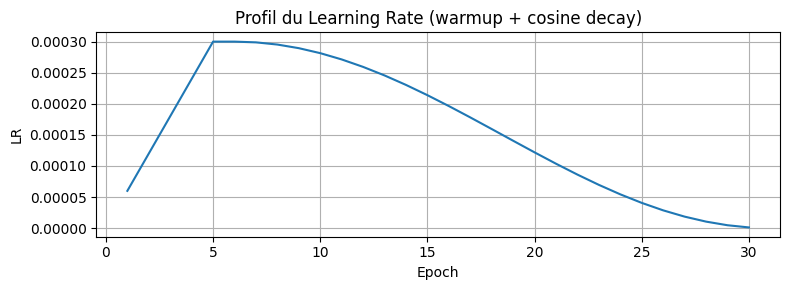

In [9]:
NUM_EPOCHS    = 30
LEARNING_RATE = 3e-4
WARMUP_EPOCHS = 5
MIN_LR        = 1e-6

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# label_smoothing=0.1 : au lieu de cible 1.0/0.0, on utilise 0.9/0.01
# légère régularisation qui améliore la généralisation

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)


def get_lr(epoch):
    """Warmup linéaire puis cosine decay."""
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
    return max(MIN_LR / LEARNING_RATE, cosine)


scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

# Aperçu du profil de LR
lrs = [get_lr(e) * LEARNING_RATE for e in range(NUM_EPOCHS)]
plt.figure(figsize=(8, 3))
plt.plot(range(1, NUM_EPOCHS + 1), lrs)
plt.title('Profil du Learning Rate (warmup + cosine decay)')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            if train:
                optimizer.zero_grad()

            logits = model(xb)
            loss   = criterion(logits, yb)

            if train:
                loss.backward()
                # Gradient clipping : limite la norme des gradients à 1.0
                # Évite les explosions de gradients (utile pour les Transformers)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct    += (logits.argmax(1) == yb).sum().item()
            total      += xb.size(0)

    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    current_lr      = optimizer.param_groups[0]['lr']

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(current_lr)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), 'best_vit_model.pth')

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} '
          f'| lr={current_lr:.2e} '
          f'| train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} '
          f'| val_loss={va_loss:.4f} val_acc={va_acc:.4f}')

print(f'\nMeilleure val_acc : {best_val_acc:.4f}')

c:\Users\depae\OneDrive\Documents\Mastere\machine_learning_ta\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

## 6. Courbes d'apprentissage

In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Validation')
axes[0].set_title('Loss (Cross-Entropy)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True)

axes[2].plot(epochs, history['lr'], color='orange')
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('vit_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Évaluation sur le jeu de test

In [ ]:
model.load_state_dict(torch.load('best_vit_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f'Accuracy sur le test : {test_acc:.4f} ({test_acc*100:.2f}%)')

In [ ]:
print(classification_report(
    all_labels, all_preds,
    target_names=[f'{i}: {n[:20]}' for i, n in enumerate(label_names)],
    digits=3
))

## 8. Matrice de confusion

In [ ]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=range(NUM_CLASSES),
            yticklabels=range(NUM_CLASSES),
            vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Vérité terrain', fontsize=12)
ax.set_title('Matrice de confusion normalisée — ViT', fontsize=14)
plt.tight_layout()
plt.savefig('vit_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualisation des cartes d'attention

L'un des avantages des Transformers : on peut **visualiser ce que le modèle regarde**  
en inspectant les poids d'attention du dernier bloc.

Pour chaque image, on extrait les poids d'attention du **CLS token** vers tous les patches.  
Ces poids indiquent quelles régions de l'image ont le plus influencé la décision du modèle.

**Comment lire la carte :**
- Zone **claire** = le modèle accorde beaucoup d'attention à ce patch
- Zone **sombre** = peu d'attention accordée

In [ ]:
# Dénormalisation pour affichage
with open('mean_image_rgb.pickle', 'rb') as f:
    mean_rgb = pickle.load(f, encoding='latin1')['mean_image_rgb']
with open('std_rgb.pickle', 'rb') as f:
    std_rgb = pickle.load(f, encoding='latin1')['std_rgb']

def denormalize(img):
    img = img * std_rgb + mean_rgb
    img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    return img.transpose(1, 2, 0)  # (H, W, 3)


def get_attention_map(image_tensor):
    """
    Extrait la carte d'attention du CLS token vers les patches
    depuis le dernier bloc Transformer.
    Retourne une carte 8×8 (une valeur par patch).
    """
    model.eval()
    with torch.no_grad():
        x = image_tensor.unsqueeze(0).to(DEVICE)  # (1, 3, 32, 32)
        _, attn_list = model(x, return_attn=True)

    # attn_list[-1] : poids du dernier bloc, shape (1, N+1, N+1)
    # Moyenne sur les têtes (si average_weights=True dans nn.MultiheadAttention)
    attn = attn_list[-1][0]  # (65, 65)

    # Attention du CLS token (ligne 0) vers tous les patches (colonnes 1:)
    cls_attn = attn[0, 1:]   # (64,) — un score par patch

    # Reshape en grille 8×8
    n_patches_side = int(math.sqrt(cls_attn.shape[0]))  # 8
    attn_map = cls_attn.reshape(n_patches_side, n_patches_side).cpu().numpy()

    return attn_map


# Affichage pour 6 images aléatoires
rng  = np.random.default_rng(7)
idxs = rng.choice(len(x_test), size=6, replace=False)

fig, axes = plt.subplots(6, 3, figsize=(9, 18))

for row, idx in enumerate(idxs):
    img_np  = x_test[idx]                        # (3, 32, 32) normalisé
    img_vis = denormalize(img_np)                 # (32, 32, 3) uint8
    truth   = y_test[idx]
    pred    = all_preds[idx]
    attn_map = get_attention_map(torch.from_numpy(img_np))

    # Col 0 : image originale
    axes[row, 0].imshow(img_vis)
    color = 'green' if truth == pred else 'red'
    axes[row, 0].set_title(f'Vrai:{truth} Préd:{pred}', color=color, fontsize=8)
    axes[row, 0].axis('off')

    # Col 1 : carte d'attention (upscalée à 32×32)
    from skimage.transform import resize as sk_resize
    attn_upscaled = sk_resize(attn_map, (32, 32), order=1, anti_aliasing=True)
    axes[row, 1].imshow(attn_upscaled, cmap='hot')
    axes[row, 1].set_title('Attention (CLS→patches)', fontsize=8)
    axes[row, 1].axis('off')

    # Col 2 : superposition
    axes[row, 2].imshow(img_vis)
    axes[row, 2].imshow(attn_upscaled, cmap='hot', alpha=0.5)
    axes[row, 2].set_title('Superposition', fontsize=8)
    axes[row, 2].axis('off')

fig.suptitle('Cartes d\'attention du Vision Transformer', fontsize=13)
plt.tight_layout()
plt.savefig('vit_attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Comparaison ViT vs CNN

| Caractéristique | CNN | Vision Transformer |
|---|---|---|
| **Inductive bias** | Fort (localité, équivariance) | Faible (apprend tout) |
| **Réceptif field** | Local → global progressivement | Global dès le premier bloc |
| **Données requises** | Peu (biais aide) | Beaucoup (mais data aug compense) |
| **Explicabilité** | Filtres appris | Cartes d'attention |
| **Complexité** | O(N) en nb de pixels | O(N²) en nb de patches |
| **Meilleur sur** | Petits datasets, images naturelles | Grands datasets, tâches complexes |

> **Sur GTSRB (32×32, 43 classes)** : le CNN est souvent légèrement meilleur car ses biais inductifs  
> (localité des features, invariance par translation) sont bien adaptés aux petites images.  
> Le ViT rattrape son retard avec de l'augmentation de données ou en augmentant la taille du modèle.

In [ ]:
# Résumé des performances
per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_5  = np.argsort(per_class_acc)[:5]
best_5   = np.argsort(per_class_acc)[-5:][::-1]

print(f'=== Résultats ViT sur GTSRB ===')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print()
print('5 classes les plus difficiles (faible recall) :')
for c in worst_5:
    print(f'  {c:2d} | {label_names[c]:<40s} | recall={per_class_acc[c]:.3f}')
print()
print('5 classes les mieux reconnues :')
for c in best_5:
    print(f'  {c:2d} | {label_names[c]:<40s} | recall={per_class_acc[c]:.3f}')

## Résumé de l'architecture

```
Image RGB (3, 32, 32)
        │
        │ PatchEmbedding : Conv2d(3→128, k=4, s=4)
        ▼
   (B, 64, 128)  — 64 patches de dim 128
        │
        │ Prepend CLS token
        ▼
   (B, 65, 128)  — 65 tokens
        │
        │ + Positional Embedding (appris)
        ▼
   (B, 65, 128)
        │
        │ × 6  TransformerBlock
        │       ├── MHSA (8 têtes) + LayerNorm + résidu
        │       └── MLP  (D→4D→D)  + LayerNorm + résidu
        ▼
   (B, 65, 128)
        │
        │ LayerNorm finale
        │ CLS token [0]
        ▼
   (B, 128)  — représentation globale de l'image
        │
        │ Linear(128 → 43)
        ▼
   (B, 43)  — logits de classification
```

Fichiers générés :
- `best_vit_model.pth` — poids du meilleur modèle
- `vit_training_curves.png` — courbes loss / accuracy / lr
- `vit_confusion_matrix.png` — matrice de confusion
- `vit_attention_maps.png` — cartes d'attention